In [9]:
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
FILE_DIR = pathlib.Path('/Users/ashhadulislam/projects/general_data/CMI/ Detect Behavior with Sensor Data/cmi-detect-behavior-with-sensor-data/')  
SEED = 42


['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject', 'orientation', 'behavior', 'phase', 'gesture', 'acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z', 'adult_child', 'age', 'sex', 'handedness', 'height_cm', 'shoulder_to_wrist_cm', 'elbow_to_wrist_cm']
(574945, 23)


rot_w                   3692
rot_z                   3692
rot_y                   3692
rot_x                   3692
row_id                     0
shoulder_to_wrist_cm       0
height_cm                  0
handedness                 0
sex                        0
age                        0
adult_child                0
acc_z                      0
sequence_type              0
acc_y                      0
acc_x                      0
gesture                    0
phase                      0
behavior                   0
orientation                0
subject                    0
sequence_counter           0
sequence_id                0
elbow_to_wrist_cm          0
dtype: int64

(571253, 23)


row_id                  0
rot_w                   0
shoulder_to_wrist_cm    0
height_cm               0
handedness              0
sex                     0
age                     0
adult_child             0
rot_z                   0
rot_y                   0
rot_x                   0
acc_z                   0
sequence_type           0
acc_y                   0
acc_x                   0
gesture                 0
phase                   0
behavior                0
orientation             0
subject                 0
sequence_counter        0
sequence_id             0
elbow_to_wrist_cm       0
dtype: int64

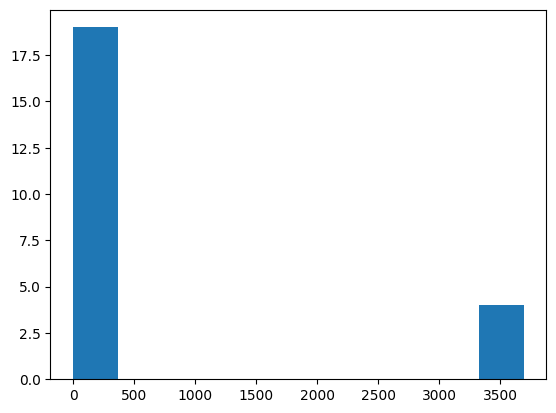

In [61]:

train_df=pd.read_csv(FILE_DIR/'train.csv')
train_demographics_df = pd.read_csv(FILE_DIR / 'train_demographics.csv')
train_df = pd.merge(train_df, train_demographics_df, how="left", on="subject")

select_cols=[]
for col in train_df.columns:
    if col.startswith('thm_') or col.startswith('tof_'):
        continue
    select_cols.append(col)
print(select_cols)

train_df=train_df[select_cols]

print(train_df.shape)
with pd.option_context('display.max_rows', None):
    display(train_df.isna().sum().sort_values(ascending=False))#

NA_vals=train_df.isna().sum().sort_values(ascending=False).values
plt.hist(NA_vals)    

train_df.dropna(inplace=True)

print(train_df.shape)
with pd.option_context('display.max_rows', None):
    display(train_df.isna().sum().sort_values(ascending=False))#

(571253, 23)


row_id                  0
rot_w                   0
shoulder_to_wrist_cm    0
height_cm               0
handedness              0
sex                     0
age                     0
adult_child             0
rot_z                   0
rot_y                   0
rot_x                   0
acc_z                   0
sequence_type           0
acc_y                   0
acc_x                   0
gesture                 0
phase                   0
behavior                0
orientation             0
subject                 0
sequence_counter        0
sequence_id             0
elbow_to_wrist_cm       0
dtype: int64

In [22]:
train_df.head()

,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,rot_x,rot_y,rot_z,adult_child,age,sex,handedness,height_cm,shoulder_to_wrist_cm,elbow_to_wrist_cm
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.683594,...,-0.355164,-0.447327,-0.809753,0,12,1,1,163.0,52,24.0
1,SEQ_000007_000001,Target,SEQ_000007,1,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.949219,...,-0.340271,-0.428650,-0.824524,0,12,1,1,163.0,52,24.0
2,SEQ_000007_000002,Target,SEQ_000007,2,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.722656,...,-0.274231,-0.356934,-0.865662,0,12,1,1,163.0,52,24.0
3,SEQ_000007_000003,Target,SEQ_000007,3,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.601562,...,-0.264160,-0.238159,-0.885986,0,12,1,1,163.0,52,24.0
4,SEQ_000007_000004,Target,SEQ_000007,4,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.566406,...,-0.218628,-0.063538,-0.914856,0,12,1,1,163.0,52,24.0


In [57]:
print(train_df.shape)
uniq_gestures=train_df.gesture.unique()
#print(uniq_gestures)
chosen_gesture=uniq_gestures[2]
print(chosen_gesture)
df_gesture=train_df[train_df['gesture']==chosen_gesture]
print(df_gesture.shape)
uniq_subjects=df_gesture.subject.unique()
#print(uniq_subjects)
chosen_subject=uniq_subjects[0]
print(chosen_subject)
df_gesture_subject=df_gesture[df_gesture['subject']==chosen_subject]
print(df_gesture_subject.shape)
uniq_sequences=df_gesture_subject.sequence_id.unique()
#print(uniq_sequences)
chosen_sequence=uniq_sequences[0]
print(chosen_sequence)
df_gesture_subject_sequence=df_gesture_subject[df_gesture_subject['sequence_id']==chosen_sequence]
print(df_gesture_subject_sequence.shape)

(571253, 23)
Write name on leg
(10138, 23)
SUBJ_052342
(184, 23)
SEQ_000016
(61, 23)


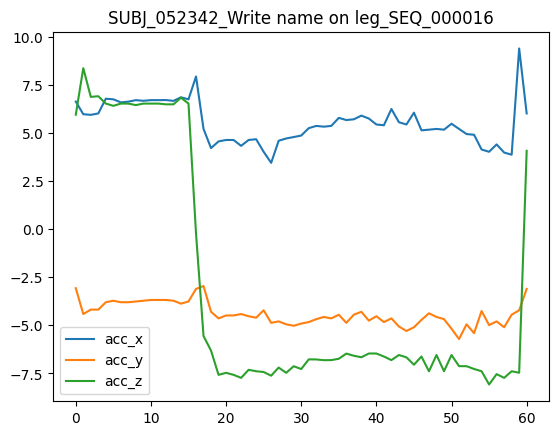

In [60]:
series_cols=[
            'acc_x','acc_y','acc_z',
             #'rot_x','rot_y','rot_z',
             ]
tseries=df_gesture_subject_sequence[series_cols].values
for i in range(len(series_cols)):
    plt.plot(tseries[:,i],label=series_cols[i])    
plt.title(f'{chosen_subject}_{chosen_gesture}_{chosen_sequence}')
plt.legend()
plt.show()

(54, 23)

In [42]:
tseries.shape

(54, 6)

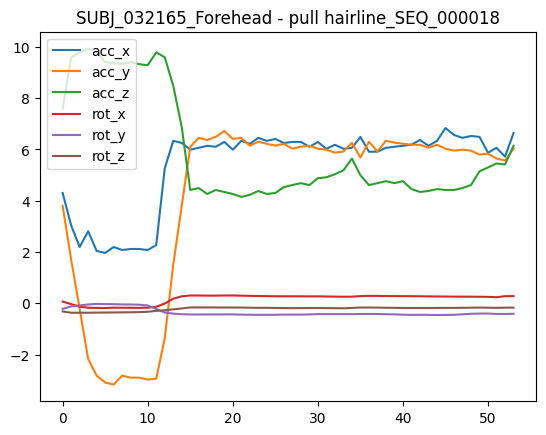